# 0101 GAN
尝试构建一个简单的 GAN 学习生成 1010 格式
```mermaid
graph LR
    S(数据源) -->|输入| D((鉴别器))
    G((生成器)) -->|生成| D
    D -->|输出| L(损失函数)
```

In [21]:
import torch
from torch import nn
import pandas as pd
from matplotlib import pyplot as plt
import random
import numpy as np

数据源和工具函数


In [2]:
# 真实数据源
def real_source():
    # 基本上是 0101，有点噪声
    return torch.FloatTensor([
        random.uniform(0.9, 1.1),
        random.uniform(-0.1, 0.1),
        random.uniform(0.9, 1.1),
        random.uniform(-0.1, 0.1)
    ])
# 随机数据源
def rand_source():
    return torch.rand(4)
# 正确标签
def right():
    return torch.FloatTensor([1])
# 错误标签
def wrong():
    return torch.FloatTensor([0])
# 生成种子
def seed():
    return torch.rand(1)

real_source()

tensor([ 1.0190,  0.0991,  0.9946, -0.0379])

鉴别器


In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
        self.loss = nn.MSELoss()
        self.optimizer = torch.optim.SGD(self.net.parameters(), lr=0.01)
        self.counter = 0
        self.progress = []

    def forward(self, x):
        return self.net(x)

    def fit(self, x, y, verbose: bool=False):
        """进行一次训练"""
        y_hat = self(x)
        l = self.loss(y_hat, y)
        self.optimizer.zero_grad()
        l.backward()
        self.optimizer.step()
        self.counter += 1
        if self.counter % 10 == 0:
            self.progress.append(l.item())
        if self.counter % 1000 == 0 and verbose:
            print(f'Discriminator step {self.counter}, loss {l.item()}')

    def plot_progress(self):
        df = pd.DataFrame({'loss': self.progress})
        df.plot(title='Discriminator Loss Progress', alpha=0.1, marker='.', grid=True)

测试鉴别器


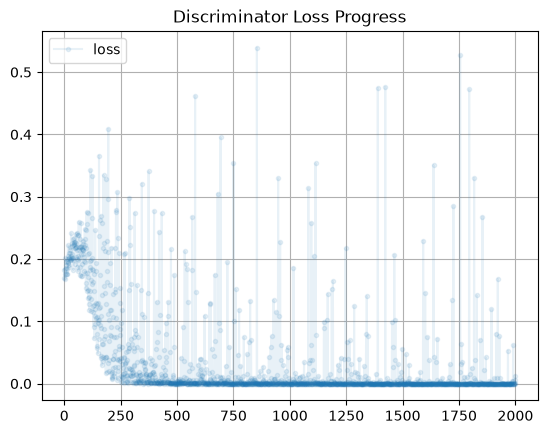

In [10]:
D = Discriminator()
for i in range(10000):
    D.fit(real_source(), right())
    D.fit(rand_source(), wrong())
D.plot_progress()

In [11]:
print(D(real_source()).data)
print(D(rand_source()).data)

tensor([0.9571])
tensor([0.0225])


生成器


In [6]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.Tanh()
        )
        self.optimizer = torch.optim.SGD(self.net.parameters(), lr=0.01)
        self.counter = 0
        self.progress = []

    def forward(self, x):
        return self.net(x)

    def fit(self, x, y, D: Discriminator):
        """进行一次训练"""
        gen = self(x)
        y_hat = D(gen)
        l = D.loss(y_hat, y)
        self.optimizer.zero_grad()
        l.backward()
        self.optimizer.step()
        self.counter += 1
        if self.counter % 10 == 0:
            self.progress.append(l.item())
        # 这里不打印了

    def plot_progress(self):
        df = pd.DataFrame({'loss': self.progress})
        df.plot(title='Generator Loss Progress', alpha=0.1, marker='.', grid=True)

检查生成器


In [12]:
G = Generator()
G(seed())

tensor([-0.3417,  0.4145,  0.5396,  0.4245], grad_fn=<TanhBackward0>)

训练生成器

```mermaid
graph LR
subgraph 训练生成器
direction LR
    G3((生成器)) -->|生成| D3((鉴别器))
    D3 -->|输出| L3(损失函数)
    L3 -->|反向传播| D3
    D3 -->|反向传播| G3
    A3([错误]) -->|标签| L3
end
subgraph 生成样本训练鉴别器
direction LR
    G2((生成器)) -->|生成| D2((鉴别器))
    D2 -->|输出| L2(损失函数)
    L2 -->|反向传播| D2
    D2 --x|detach| G2
    A2([错误]) -->|标签| L2
end
subgraph 真实样本训练鉴别器
direction LR
    S(数据源) -->|输入| D((鉴别器))
    D -->|输出| L(损失函数)
    L -->|反向传播| D
    A([正确]) -->|标签| L
end
```


In [29]:
def train_gan(D: Discriminator, G: Generator, num_steps: int=10000, get_evolve: bool=False):
    img_list = []
    for i in range(num_steps):
        # 真实样本训练鉴别器
        D.fit(real_source(), right())
        # 生成样本训练鉴别器，detach 防止梯度回传到生成器
        D.fit(G(seed()).detach(), wrong())
        # 训练生成器
        G.fit(seed(), right(), D)
        if get_evolve and i % 1000 == 0:
            img_list.append(G(seed()).detach().numpy())
    return img_list

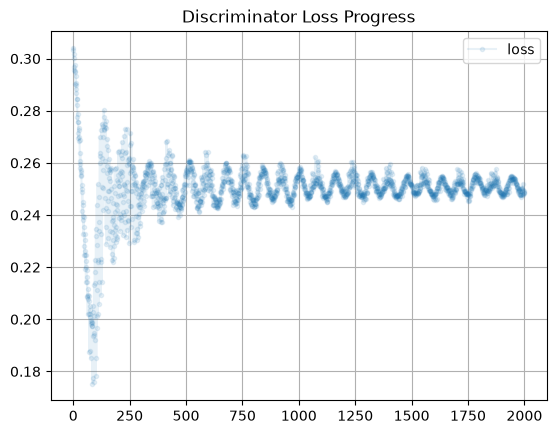

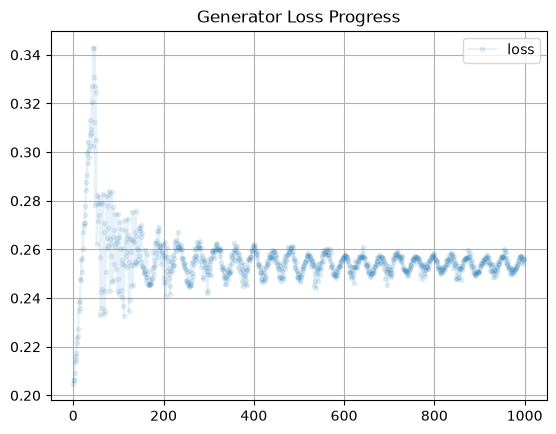

In [17]:
D = Discriminator()
G = Generator()
train_gan(D, G)
D.plot_progress()
G.plot_progress()

In [18]:
G(seed()).data

tensor([ 0.9977,  0.1266,  0.9970, -0.0322])

可视化格式演变


In [32]:
D = Discriminator()
G = Generator()
img_list = train_gan(D, G, get_evolve=True)

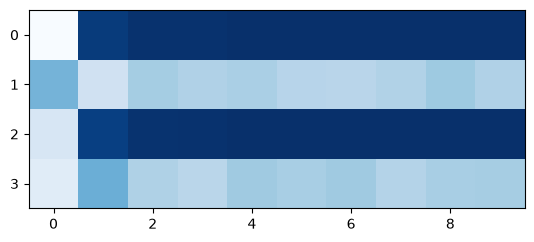

In [34]:
plt.imshow(np.array(img_list).T, cmap='Blues')